## Global average temperature chart

This notebook recreates the Copernicus Climate Change Service (C3S)
"Climate Pulse" chart of global daily surface air temperature.

The key feature used here is the `ekp.climatology` namespace.  When you pass a
multi-year time series to any method under `ekp.climatology` — such as
`ekp.climatology.line()` — earthkit-plots automatically splits the data by year
and folds each year onto a shared Jan–Dec x-axis.  This means you can hand it a
single continuous `DataArray` spanning decades and get a spaghetti plot of
individual years with no manual looping or date arithmetic.

The `ekp.climatology` namespace also understands climatology data directly.  If
you pass a `DataArray` with a `dayofyear` dimension (instead of a `time`
dimension), it is mapped onto the same Jan–Dec axis as a reference line — no
conversion needed.  This makes it straightforward to overlay a long-term mean
alongside individual years in a single chart.

In [1]:
import earthkit.plots as ekp
import earthkit.data as ekd
import pandas as pd

### Loading the data

We download the pre-processed CSV from the C3S Climate Pulse data
portal.  The file contains daily global mean 2-metre temperature in °C
for every year since 1940, plus a 1991–2020 climatological mean column
(`clim_91-20`) used as the reference line.

In [2]:
C3S_RED = "#941333"

csv_file = "era5_daily_series_2t_global.csv"
data = ekd.from_source(
    "url",
    "https://sites.ecmwf.int/data/climatepulse/data/series/era5_daily_series_2t_global.csv",
)
data.to_target("file", csv_file)
df = pd.read_csv(csv_file, comment="#", index_col="date", parse_dates=True).round(2)
df.head()

,Unnamed: 0,2t,clim_91-20,ano_91-20,status
date,,,,,
1940-01-01,0,11.72,12.48,-0.76,FINAL
1940-01-02,1,11.66,12.47,-0.81,FINAL
1940-01-03,2,11.66,12.47,-0.80,FINAL
1940-01-04,3,11.68,12.46,-0.78,FINAL
1940-01-05,4,11.60,12.45,-0.85,FINAL


### Preparing the data

We convert the relevant DataFrame columns to `xr.DataArray` objects before
plotting.  Time series data uses a `time` dimension — earthkit-plots will split
this automatically by year when plotting under the `ekp.climatology` namespace.
The 1991–2020 climatological mean is reduced to a single annual cycle by
averaging per day-of-year and stored with a `dayofyear` dimension, which
earthkit-plots maps directly onto the shared Jan–Dec axis.

In [3]:
import xarray as xr


def series_to_da(s, units="celsius", long_name="2 m temperature"):
    """Convert a pandas Series with a DatetimeIndex to a time-indexed DataArray."""
    return xr.DataArray(
        s.values,
        coords={"time": s.index.values},
        dims=["time"],
        attrs={"units": units, "long_name": long_name},
    )


# 1991–2020 daily climatology: mean per day-of-year across the base period
clim_series = (
    df.loc["1991":"2020", "clim_91-20"]
    .groupby(df.loc["1991":"2020"].index.dayofyear)
    .mean()
)
clim_daily = xr.DataArray(
    clim_series.values,
    coords={"dayofyear": clim_series.index.values},
    dims=["dayofyear"],
)

# Convert temperature slices to DataArrays upfront
temp_background = series_to_da(df.loc["1940":"2022", "2t"])
temp_2023 = series_to_da(df.loc["2023":"2023", "2t"])
temp_2024 = series_to_da(df.loc["2024":"2024", "2t"])
temp_latest = series_to_da(df["2t"].iloc[[-1]])

### Drawing the chart

`ekp.climatology.line()` accepts the full 1940–2022 time series as a single
DataArray and automatically splits it into one line per year, all folded onto the
same Jan–Dec x-axis.  Subsequent `chart.line()` calls on the returned object work
the same way — a single-year DataArray produces one line, a multi-year DataArray
produces one line per year.

`clim_daily` has a `dayofyear` dimension rather than `time`, so earthkit-plots
treats it as a pre-computed annual cycle and maps it directly onto the axis
without any year-splitting.

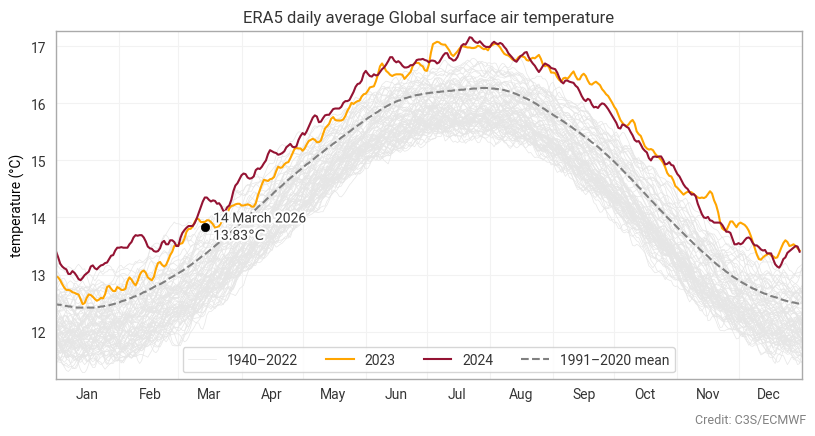

In [4]:
import matplotlib.patheffects as pe

chart = ekp.climatology.line(
    temp_background,
    linewidth=0.5,
    color="#e6e6e6",
    label="1940–2022",
)

chart.line(temp_2023, color="orange", label="2023")
chart.line(temp_2024, color=C3S_RED, label="2024")

chart.scatter(temp_latest, color="black", zorder=10)
chart.annotate(
    "{time:%-d %B %Y}\n{value}{units}",
    temp_latest,
    path_effects=[pe.withStroke(linewidth=3, foreground="white")],
    verticalalignment="center",
    xytext=(6, 0),
    textcoords="offset points",
)

chart.line(clim_daily, color="grey", linestyle="--", label="1991–2020 mean")

chart.xticks(frequency="M", period=True)
chart.ylabel("temperature (°C)")

chart.legend(ncols=5)
chart.title("ERA5 daily average Global surface air temperature")
chart.attribution("Credit: C3S/ECMWF", location="lower right")

chart.show()

### What the chart shows

The grey envelope formed by all historical years gives an immediate sense
of natural variability.  Years that depart strongly from the envelope —
particularly at the top — indicate anomalously warm periods.  The bold
red line for 2024 makes it easy to see how the most recent year compares
to every year on record.